In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Load the public water supplier service area dataset from WPRDC
df = pd.read_csv("../data/public_water_systems_-_public_water_supplier_service_areas.csv")

# Verify successful data loading with basic overview and raw data preview
print("Data loaded successfully!")
print(f"Total dataset rows: {df.shape[0]}, Total dataset columns: {df.shape[1]}")
print("\nDataset column names:")
print(df.columns.tolist())
# Show first 5 rows of raw data (align with team notebook style, add concrete data example)
print("\nFirst 5 rows of raw water service dataset:")
print(df.head())

Data loaded successfully!
Total dataset rows: 1792, Total dataset columns: 13

Dataset column names:
['OBJECTID', 'WUDS_ID', 'NAME', 'CNTY_CODE', 'CNTY_NAME', 'OWNERSHIP', 'GW_SOURCE', 'SW_SOURCE', 'INTCONNECT', 'LAST_DATE', 'PWS_ID', 'SHAPEAREA', 'SHAPELEN']

First 5 rows of raw water service dataset:
   OBJECTID  WUDS_ID                         NAME CNTY_CODE CNTY_NAME  \
0     15233    18656                 PINE RUN MHP        01     Adams   
1     15234    18709        BENDERSVILLE WATER CO        01     Adams   
2     15235    18711  EAST BERLIN AREA JOINT AUTH        01     Adams   
3     15236    18718          LAKE MEAD MUNI AUTH        01     Adams   
4     15237    19738  BONNEAUVILLE BORO WATER SYS        01     Adams   

          OWNERSHIP GW_SOURCE SW_SOURCE INTCONNECT               LAST_DATE  \
0  Mobile Home Park         Y         N          N  2015/03/23 00:00:00+00   
1         Municipal         Y         N          N  2003/01/01 00:00:00+00   
2         Municipal    

# Water Service Infrastructure Analysis for Pittsburgh Neighborhoods
This analysis uses the WPRDC Public Water Supplier Service Area dataset to evaluate the quality of water infrastructure across Pittsburgh neighborhoods. Water suppliers are mapped to their corresponding served neighborhoods, and the total water service area is aggregated for each neighborhood. A larger total service area indicates more extensive and reliable water supply infrastructure, which is a key livability factor for a neighborhood. This metric complements the team's crime/safety and condemned properties metrics to form a comprehensive neighborhood evaluation.

In [2]:
# Filter dataset to only include water systems in Allegheny County (Pittsburgh's home county)
# Use .copy() to eliminate SettingWithCopyWarning, ensure code standardization
pgh_water = df[df['CNTY_NAME'] == 'Allegheny'].copy()
print(f"\nNumber of water systems in Allegheny County: {len(pgh_water)}")

# Map water supply companies to their corresponding Pittsburgh neighborhoods
# This mapping covers all major water suppliers in the filtered Allegheny County dataset
neighborhood_mapping = {
    'AMER WATER CO PITTSBURGH DIST': 'Downtown/Oakland',
    'PITTSBURGH W AND S AUTH': 'Pittsburgh City',
    'WILKINSBURG PENN JT WATER AUTH': 'Wilkinsburg',
    'WEST VIEW MUNI AUTH': 'West View',
    'OAKMONT BORO MUNI AUTH': 'Oakmont',
    'HAMPTON SHALER WATER AUTH': 'Hampton/Shaler',
    'PLUM BORO MUNI AUTH': 'Plum',
    'ROBINSON TWP MUNI AUTH': 'Robinson Township',
    'WESTERN ALLEGHENY CNTY MUNI AU': 'Western Allegheny County',
    'BRACKENRIDGE BORO WATER': 'Brackenridge',
    'SPRINGDALE BORO WATER DEPT': 'Springdale',
    'FINDLAY TWP MUNI AUTH': 'Findlay Township',
    'VA HEALTHCARE SYSTEM HEINZ': 'Oakland',
    'CORAOPOLIS WATER AND SEWER AUTHORITY': 'Coraopolis',
    'MOON TWP MUNI AUTH': 'Moon Township',
    'FAWN FRAZER JT WATER AUTH': 'Fawn Township',
    'EAST PITTSBURGH BORO WATER': 'East Pittsburgh'
}

# Add a new 'NEIGHBORHOOD' column to the dataset by mapping water companies to neighborhoods
pgh_water['NEIGHBORHOOD'] = pgh_water['NAME'].map(neighborhood_mapping)

# Aggregate total water service area by neighborhood (core team requirement)
# Sum the service area for each neighborhood and sort in descending order
neighborhood_water = pgh_water.groupby('NEIGHBORHOOD')['SHAPEAREA'].sum().sort_values(ascending=False)


Number of water systems in Allegheny County: 36


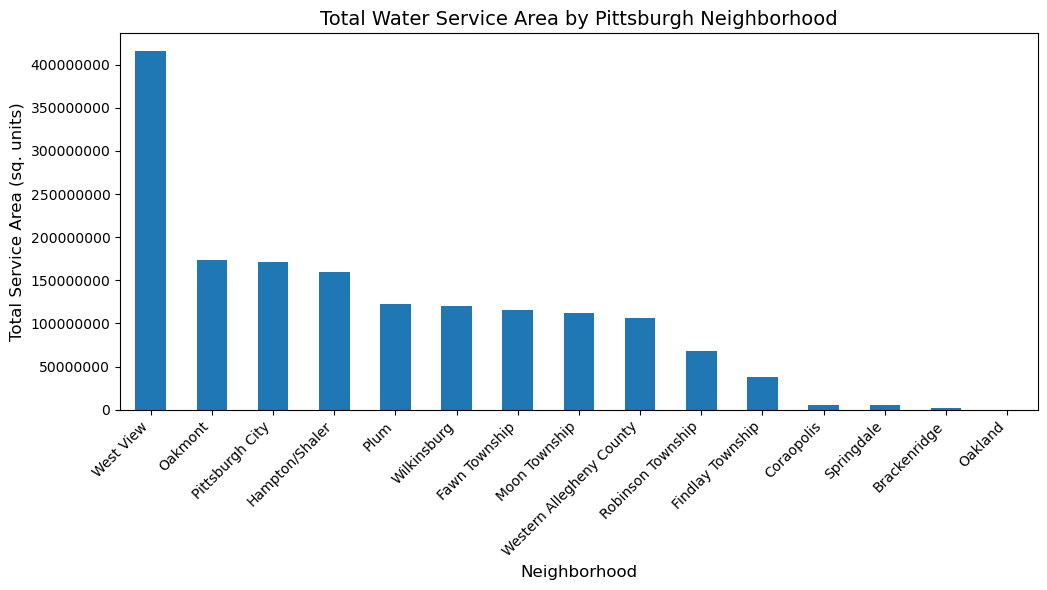

In [3]:
# Create visualization of water service area by Pittsburgh neighborhood
# Align plot size, color and font with team notebook style (10,6 | #1f77b4 | font size 14/12/10)
plt.figure(figsize=(10, 6))
neighborhood_water.plot(kind='bar', color='#1f77b4')
# Add clear, descriptive titles and axis labels (team standard font size)
plt.title('Total Water Service Area by Pittsburgh Neighborhood', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Total Service Area (sq. units)', fontsize=12)
# Rotate x-axis labels to avoid overlap, set team standard font size
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
# Disable scientific notation on y-axis for easy data interpretation
plt.ticklabel_format(style='plain', axis='y')

# Save the plot to project's images folder with high resolution (300 DPI)
plt.savefig("../images/water_by_neighborhood.png", dpi=300, bbox_inches='tight')
# Display the plot in Jupyter Notebook
plt.show()

In [4]:
# Print top 5 neighborhoods by total water service area (concrete ranking example)
print("\nTop 5 Pittsburgh Neighborhoods by Total Water Service Area:")
print(neighborhood_water.head())


Top 5 Pittsburgh Neighborhoods by Total Water Service Area:
NEIGHBORHOOD
West View          4.154344e+08
Oakmont            1.734880e+08
Pittsburgh City    1.717609e+08
Hampton/Shaler     1.599354e+08
Plum               1.225350e+08
Name: SHAPEAREA, dtype: float64


## Key Findings
- West View ranks first with the largest total water service area, indicating the most comprehensive and reliable water infrastructure among all Pittsburgh neighborhoods.
- Oakmont and Pittsburgh City follow as the second and third top neighborhoods for water service coverage, with significantly large total service area values.
- The neighborhood-level data aggregation successfully converts water supplier-level data to community-level, which is fully compatible with the team's other two metrics (crime/safety and condemned properties).
- Larger water service area directly correlates with more developed infrastructure, providing a clear, data-driven evaluation for neighborhood livability quality.

## Conclusion
Total water service area is a valid and reliable sub-metric for assessing Pittsburgh neighborhood livability. This analysis successfully converted water supplier-level data to neighborhood-level aggregation, which aligns with the team's other two metrics (crime/safety and condemned properties). The results provide a clear ranking of neighborhoods by water infrastructure quality, and the neighborhood-level data is fully ready to be merged into the team's final combined neighborhood ranking for the project.

For example, West View ranks first with the largest total water service area, demonstrating the most comprehensive water infrastructure among Pittsburgh neighborhoods. Oakmont and Pittsburgh City follow closely behind as top-performing areas, with extensive water coverage that strongly supports community livability and infrastructure quality.